# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Victor Scholten| 6434789 |
| Farzat Darboli | 6535925 |
| Mees van Zeeland| 6488021 |
| Planning Groep: 36     |Tijdstip / Tijdspanne  |
|---|---|
| condensator simulatie| 12:30 |
| eigen sensor ontworpen | 17:30 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| 13:45 |
| Pauze 1: | 12:30-13:45|
| Pauze 2| 15:30-15:45 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
![schetsinclberekening](fotos/schetsinclberekening.jpg)

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854187817e-12  # F/m
def vlakkeplaat(A, d, eps_r):
    C = (epsilon0 * eps_r * A) / d
    #A: Oppervlakte van de platen (m^2) d: Afstand tussen de platen (m)
    #print(C)
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = vlakkeplaat(0.01, 0.001, 2.0)


print(f"Berekende capaciteit plaatcondensator groep 36 is {C*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 36 is 177.1 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![sanitycheck](fotos/sanitycheck.png)


![plaatjemetkarton](fotos/plaatjemetkarton.png)


### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 36| 177pF |0.89V | 1.19V |237pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![naam](fotos/syntheseschets1.png)
![naam](fotos/syntheseschets2.png)
![naam](fotos/syntheseschets3.png)

## Opdracht 3: Welke sensor gaan jullie maken?


Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in

![naam](fotos/definitieveschets.png)

[0.01       0.00800737 0.0064118  0.00513417 0.00411112 0.00329193
 0.00263597 0.00211072 0.00169013 0.00135335]


Text(0, 0.5, 'Capaciteit (pF)')

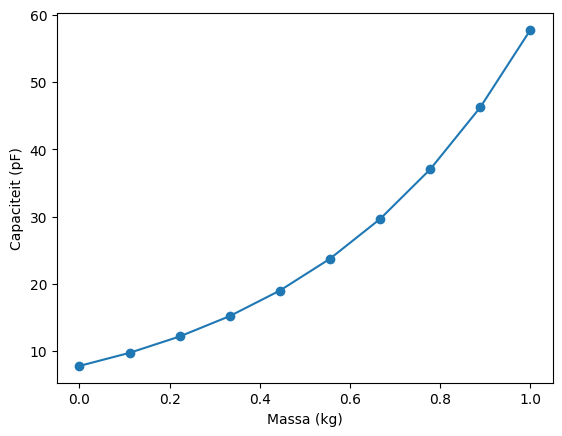

In [4]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt 
A = (60+20*np.sqrt(2))*10**-4 # m^2
epsilon_lucht = 1.0
m = np.linspace(0, 1, 10) # kg
d_0 = 0.01 # m (gemeten met geodriehoek zonder gewicht)
a = 2 #aanname m/kg 
def d(d_0, a, m):
    return d_0*np.exp(-a*m)

d_list = d(d_0, a, m)
print(d_list)
C = vlakkeplaat(A, d_list, epsilon_lucht)
plt.plot(m, C*1e12, 'o-')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')



## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 30 pF |140mV |
| gemiddelde capaciteit| 75 pF |370mV |
| maximale capaciteit| 120 pF|600mV |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![naam](fotos/eindfoto2.png)
![naam](fotos/eindfoto3.png)
![naam](fotos/eindfoto4.png)
![naam](fotos/eindfoto5.png)
![naam](fotos/werkendeopst1.png)

## Opdracht 7: Plot de kalibratiegrafiek.

[0.01       0.00825307 0.00579262 0.00486752 0.00312235 0.00254107
 0.00210136 0.00160414 0.00130029 0.00096328 0.00044157]


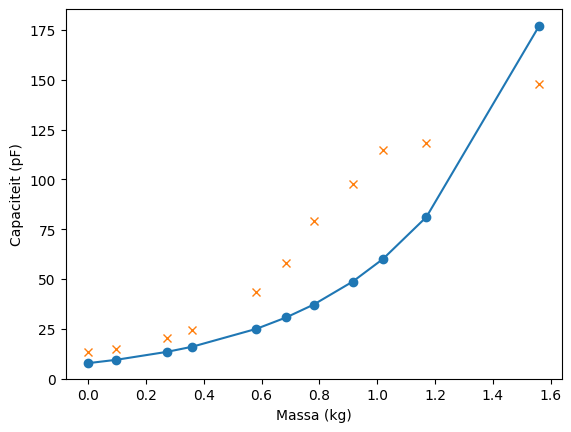

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A = (60+20*np.sqrt(2))*10**-4 # m^2
epsilon_lucht = 1.0
m = np.array([0, 0.096, 0.273, 0.360, 0.582, 0.685, 0.780, 0.915, 1.020, 1.170, 1.560 ]) # kg gemeten massa's
d_0 = 0.01 # m (gemeten met geodriehoek zonder gewicht)
a = 2 #aanname m/kg 
def d(d_0, a, m):
    return d_0*np.exp(-a*m)

C_waarde = np.array([13.2, 14.8, 20.2, 24.5, 43.5, 58.0, 79.3, 97.9, 115.0 , 118.5, 147.8]) # pF gemeten capaciteiten

d_list = d(d_0, a, m)
print(d_list)
C = vlakkeplaat(A, d_list, epsilon_lucht)
plt.plot(m, C*1e12, 'o-')
plt.plot(m, C_waarde, 'x')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.ylim(0,)
plt.savefig('plot_resultaat.png')
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1: meer schuimblokjes, waardoor het meer gewicht kan hebben en dus meer kan meten.
* verbetering 2: Een grotere oppervlakte waardoor er minder fluctuaties zijn en het systeem nauwkeuriger wordt. 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](fotos/eindfoto2.png)

(0.0, 120.0)

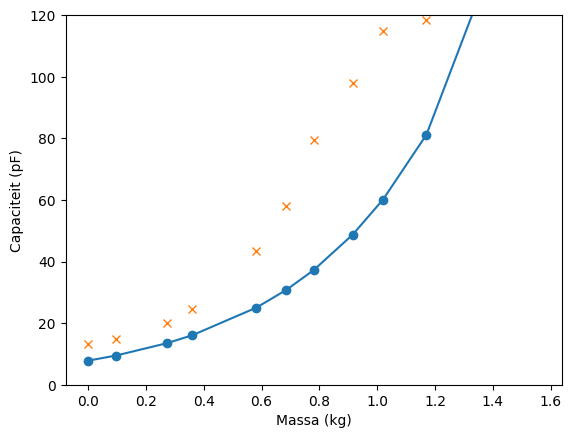

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

plt.plot(m, C*1e12, 'o-')
plt.plot(m, C_waarde, 'x')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.ylim(0,120)

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

De sensor is geschikt om massa te meten. Er is een duidelijk veband zichtbaar tussen de capaciteit en het gewicht. We hadden geen tijd voor een iteratie, maar zie opdr 9 voor mogelijke iteraties. Er is een significant verschil tussen de voorspelling en de daadwerkelijke metingen omdat de veerconstante, a, onbekend was en er een schatting is gemaakt. Voor onze specifieke sensor klopt de vlakkeplaatcondensator goed genoeg maar als de platen te dicht op elkaar komen werkt deze niet meer. Schommelingen in de capaciteitswaarde waren duidelijk merkbaar tijdens de kalibratie, doormiddel van een timer zijn de waarden allemaal gelijk ten opzichte van elkaar afgenomen, hiermee is wel duidelijk dat er een behoorlijke onzekerheid in deze opstelling een rol speelt en dat de gekozen opstelling met schuimpjes duidelijk minder effectief zal zijn dan een simpele kookweegschaal. 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
![schetsinclberekening](fotos/schetsinclberekening.jpg)
#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![sanitycheck](fotos/sanitycheck.png)


![plaatjemetkarton](fotos/plaatjemetkarton.png)
### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 36| 177pF |0.89V | 1.19V |237pF|


#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in

![naam](fotos/definitieveschets.png)

#### Voeg hier de foto's van je sensoren in actie in.
![naam](fotos/eindfoto2.png)
![naam](fotos/eindfoto3.png)
![naam](fotos/eindfoto4.png)
![naam](fotos/eindfoto5.png)
![naam](fotos/werkendeopst1.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
![schetsinclberekening](fotos/schetsinclberekening.jpg)
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854187817e-12  # F/m
def vlakkeplaat(A, d, eps_r):
    C = (epsilon0 * eps_r * A) / d
    #A: Oppervlakte van de platen (m^2) d: Afstand tussen de platen (m)
    #print(C)
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.
#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![sanitycheck](fotos/sanitycheck.png)
![plaatjemetkarton](fotos/plaatjemetkarton.png)
#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![naam](fotos/syntheseschets1.png)
![naam](fotos/syntheseschets2.png)
![naam](fotos/syntheseschets3.png)
#### Voeg hier de foto's van je sensoren in actie in.
![naam](fotos/eindfoto2.png)
![naam](fotos/eindfoto3.png)
![naam](fotos/eindfoto4.png)
![naam](fotos/eindfoto5.png)
![naam](fotos/werkendeopst1.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A = (60+20*np.sqrt(2))*10**-4 # m^2
epsilon_lucht = 1.0
m = np.array([0, 0.096, 0.273, 0.360, 0.582, 0.685, 0.780, 0.915, 1.020, 1.170, 1.560 ]) # kg gemeten massa's
d_0 = 0.01 # m (gemeten met geodriehoek zonder gewicht)
a = 2 #aanname m/kg 
def d(d_0, a, m):
    return d_0*np.exp(-a*m)

C_waarde = np.array([13.2, 14.8, 20.2, 24.5, 43.5, 58.0, 79.3, 97.9, 115.0 , 118.5, 147.8]) # pF gemeten capaciteiten

d_list = d(d_0, a, m)
print(d_list)
C = vlakkeplaat(A, d_list, epsilon_lucht)
plt.plot(m, C*1e12, 'o-')
plt.plot(m, C_waarde, 'x')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.ylim(0,)
plt.savefig('plot_resultaat.png')
plt.show()

![plot](plot_resultaat.png)

# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

plt.plot(m, C*1e12, 'o-')
plt.plot(m, C_waarde, 'x')
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.ylim(0,120)

Vul hier de conclusie in

De sensor is geschikt om massa te meten. Er is een duidelijk veband zichtbaar tussen de capaciteit en het gewicht. We hadden geen tijd voor een iteratie, maar zie opdr 9 voor mogelijke iteraties. Er is een significant verschil tussen de voorspelling en de daadwerkelijke metingen omdat de veerconstante, a, onbekend was en er een schatting is gemaakt. Voor onze specifieke sensor klopt de vlakkeplaatcondensator goed genoeg maar als de platen te dicht op elkaar komen werkt deze niet meer. Schommelingen in de capaciteitswaarde waren duidelijk merkbaar tijdens de kalibratie, doormiddel van een timer zijn de waarden allemaal gelijk ten opzichte van elkaar afgenomen, hiermee is wel duidelijk dat er een behoorlijke onzekerheid in deze opstelling een rol speelt en dat de gekozen opstelling met schuimpjes duidelijk minder effectief zal zijn dan een simpele kookweegschaal. 
